# Fluid Mechanics — Chapter 8: Visualizations

Companion notebook for Ch. 8 (*Boundary Layers*) problem-solution slides.

| Problem | Figure | Description |
|---------|--------|-------------|
| 8.2  | `fig_8_2_hiemenz.png`       | Hiemenz stagnation-flow profile $f'(\eta)$ |
| 8.3  | `fig_8_3_falkner_skan.png`  | Falkner–Skan profiles for several $m$ |
| 8.4  | `fig_8_4_jet.png`           | 2-D jet: $\mathrm{sech}^2$ profile & width |
| 8.5  | `fig_8_5_wake.png`          | Far-wake Gaussian profiles at two $x$ |
| 8.7  | `fig_8_7_jeffery_hamel.png` | Jeffery–Hamel $f(\eta)$ for several $R$ |
| 8.8  | `fig_8_8_karman_disc.png`   | Von Kármán disc: $f,g,h$ vs $\xi$ |

All figures saved to `../figures/` for use in the Quarto slides.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, odeint
from scipy.optimize import brentq
from pathlib import Path

FIG_DIR = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

BG = 'white'
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG,
    'text.color': '#1a1a2e', 'axes.labelcolor': '#1a1a2e',
    'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.edgecolor': '#888888', 'grid.color': '#dddddd',
    'font.family': 'serif', 'font.size': 12,
    'axes.titlesize': 13, 'axes.labelsize': 12,
    'figure.dpi': 120,
})
TEAL   = '#007a63'
ORANGE = '#b5470a'
RED    = '#c0003a'
GREEN  = '#2e7d32'
BLUE   = '#1565c0'
MAUVE  = '#6a0dad'
print(f'Figures will be saved to: {FIG_DIR.resolve()}')

Figures will be saved to: /figures


---
## Problem 8.2 — Hiemenz Stagnation-Point Flow

Numerically solve $f'''+ff''+1-f'^2=0$, $f(0)=f'(0)=0$, $f'(\infty)=1$.


f''(0) = 1.232588  (expected ~1.2326)


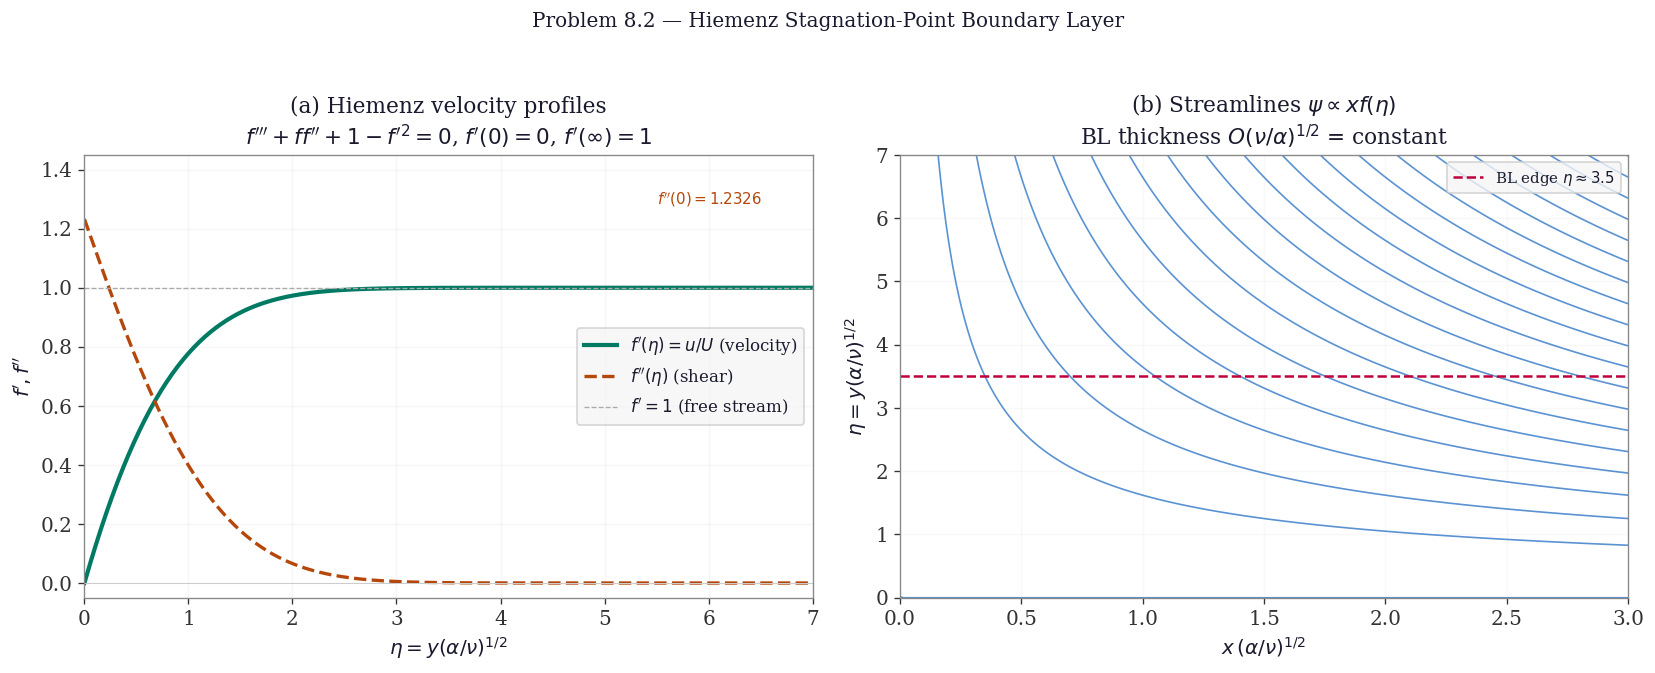

Saved: fig_8_2_hiemenz.png


In [2]:
from scipy.integrate import odeint

def hiemenz_rhs_ode(y, eta):
    f, fp, fpp = y
    fppp = fp**2 - f*fpp - 1
    return [fp, fpp, fppp]

eta = np.linspace(0, 7, 400)

def shoot(fpp0):
    sol = odeint(hiemenz_rhs_ode, [0, 0, fpp0], eta)
    return sol[-1, 1] - 1.0   # f'(end) - 1

fpp0_star = brentq(shoot, 1.23, 1.25)
print(f"f''(0) = {fpp0_star:.6f}  (expected ~1.2326)")

sol = odeint(hiemenz_rhs_ode, [0, 0, fpp0_star], eta)
f, fp, fpp = sol[:, 0], sol[:, 1], sol[:, 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)

ax = axes[0]
ax.plot(eta, fp,  color=TEAL,   lw=2.5, label=r"$f'(\eta)=u/U$ (velocity)")
ax.plot(eta, fpp, color=ORANGE, lw=2.0, ls='--', label=r"$f''(\eta)$ (shear)")
# Don't plot f itself — it grows and confuses the scale
ax.axhline(1, color='#aaaaaa', lw=0.8, ls='--', label="$f'=1$ (free stream)")
ax.axhline(0, color='#cccccc', lw=0.6)
ax.text(5.5, fpp0_star+0.05, f"$f''(0)={fpp0_star:.4f}$",
        color=ORANGE, fontsize=9)
ax.set_xlabel(r'$\eta = y(\alpha/\nu)^{1/2}$')
ax.set_ylabel("$f', f''$")
ax.set_title('(a) Hiemenz velocity profiles\n'
             r"$f'''+ff''+1-f'^2=0$, $f'(0)=0$, $f'(\infty)=1$",
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5', loc='center right')
ax.set_xlim(0, 7); ax.set_ylim(-0.05, 1.45)
ax.grid(True, alpha=0.25)

ax = axes[1]
x_arr = np.linspace(0, 3, 200)
ETA_g, X_g = np.meshgrid(eta, x_arr)
fp_2d = np.interp(ETA_g.ravel(), eta, f).reshape(ETA_g.shape)
PSI = X_g * fp_2d
cf = ax.contour(X_g, ETA_g, PSI, levels=20, colors='#1565c0',
                linewidths=1.0, alpha=0.7)
ax.axhline(3.5, color=RED, lw=1.5, ls='--',
           label=r'BL edge $\eta\approx3.5$')
ax.set_xlabel(r'$x\,(\alpha/\nu)^{1/2}$')
ax.set_ylabel(r'$\eta = y(\alpha/\nu)^{1/2}$')
ax.set_title('(b) Streamlines $\\psi\\propto x f(\\eta)$\n'
             'BL thickness $O(\\nu/\\alpha)^{1/2}$ = constant',
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='upper right')
ax.set_ylim(0, 7)
ax.grid(True, alpha=0.2)

fig.suptitle('Problem 8.2 — Hiemenz Stagnation-Point Boundary Layer',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_8_2_hiemenz.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_8_2_hiemenz.png')


---
## Problem 8.3 — Falkner–Skan Profiles

$f'''+ff''+\beta(1-f'^2)=0$, $\beta=2m/(m+1)$, for several $m$ values.


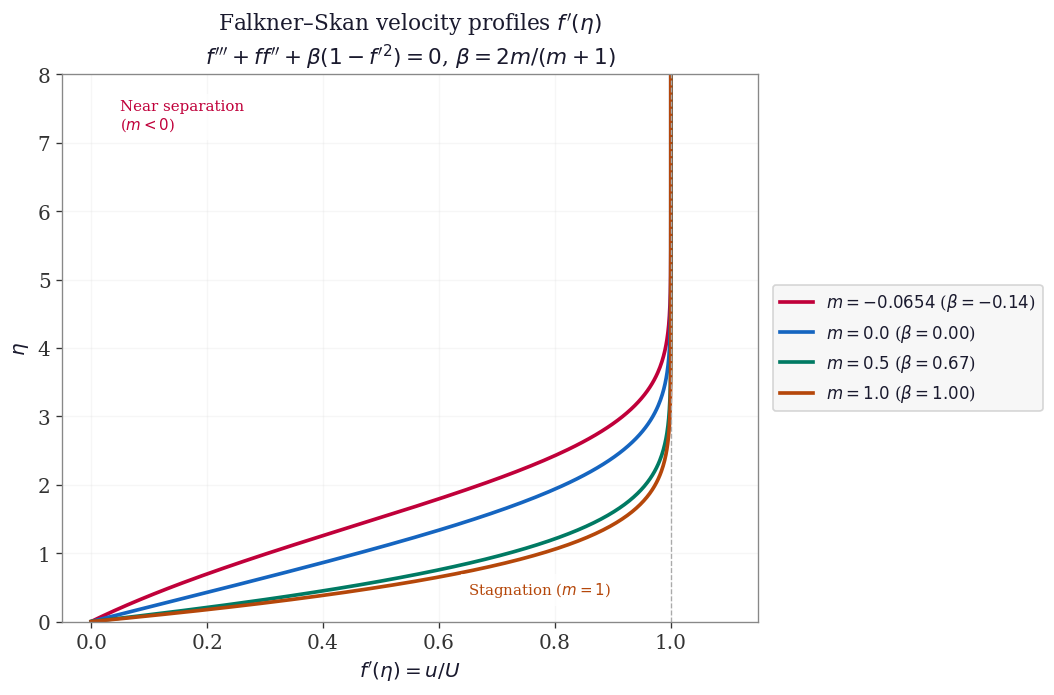

Saved: fig_8_3_falkner_skan.png


In [3]:
from scipy.integrate import odeint

def falkner_ode(y, eta, beta):
    f, fp, fpp = y
    return [fp, fpp, -f*fpp - beta*(1 - fp**2)]

eta = np.linspace(0, 8, 300)

def shoot_fs(fpp0, beta):
    sol = odeint(falkner_ode, [0, 0, fpp0], eta, args=(beta,))
    return sol[-1, 1] - 1.0

cases = [
    (-0.0654, 2*(-0.0654)/(1-0.0654), 0.15, 0.25),
    (0.0,     0.0,                     0.3,  0.5 ),
    (0.5,     2*0.5/1.5,               1.02, 1.05),
    (1.0,     1.0,                     1.23, 1.25),
]
colors_m = [RED, BLUE, TEAL, ORANGE]

fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)

lines = []
for (m, beta, lo, hi), col in zip(cases, colors_m):
    fpp0 = brentq(shoot_fs, lo, hi, args=(beta,))
    sol  = odeint(falkner_ode, [0, 0, fpp0], eta, args=(beta,))
    lbl = f'$m={m}$ ($\\beta={beta:.2f}$)'
    ln, = ax.plot(sol[:, 1], eta, color=col, lw=2.2, label=lbl)
    lines.append(ln)

ax.axvline(1, color='#aaaaaa', lw=0.8, ls='--')
ax.set_xlabel("$f'(\\eta) = u/U$")
ax.set_ylabel(r'$\eta$')
ax.set_title("Falkner–Skan velocity profiles $f'(\\eta)$\n"
             r"$f'''+ff''+\beta(1-f'^2)=0$, $\beta=2m/(m+1)$",
             color='#1a1a2e')
# Legend outside right edge — no overlap
ax.legend(fontsize=10, facecolor='#f5f5f5',
          loc='center left', bbox_to_anchor=(1.01, 0.5))
ax.set_xlim(-0.05, 1.15); ax.set_ylim(0, 8)
ax.grid(True, alpha=0.25)
# Annotations — placed carefully to avoid curves
ax.text(0.05, 7.2, 'Near separation\n($m<0$)', color=RED,   fontsize=9,
        bbox=dict(fc='white', ec='none', alpha=0.7))
ax.text(0.65,  0.4, 'Stagnation ($m=1$)',        color=ORANGE, fontsize=9,
        bbox=dict(fc='white', ec='none', alpha=0.7))

fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_8_3_falkner_skan.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_8_3_falkner_skan.png')


---
## Problem 8.4 — 2-D Jet: $\mathrm{sech}^2$ Profile

$u = \frac{1}{3}(3M^2/4\nu^2\rho x)^{1/3}\mathrm{sech}^2(\frac{1}{2}\eta)$; width $\propto x^{1/3}$.


A = 0.629961  (from momentum constraint, not 0.5)
int f'^2 deta = 1.3333  (expected 4/3 = 1.3333)


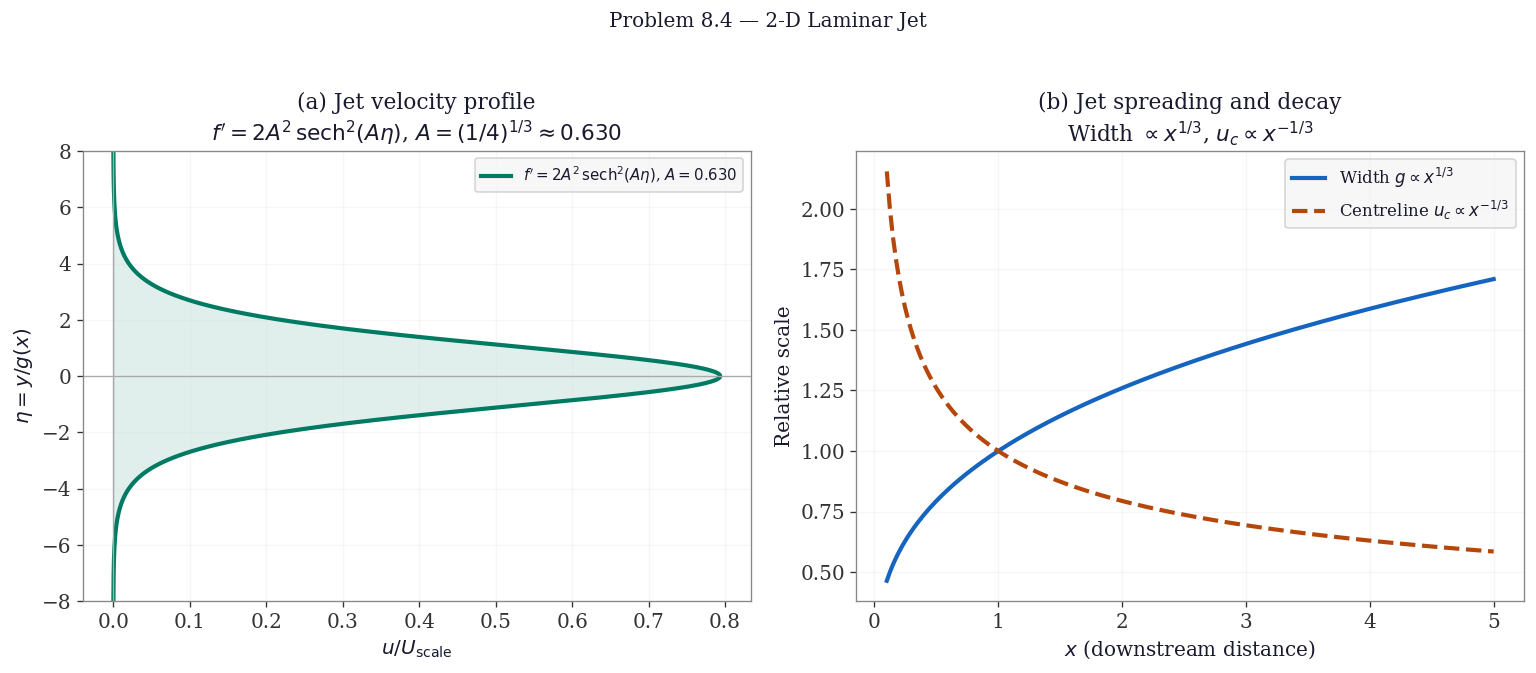

Saved: fig_8_4_jet.png


In [4]:
# Correct A from int f'^2 deta = 4/3: 16A^3/3 = 4/3 => A = (1/4)^{1/3}
A = (1/4)**(1/3)
print(f'A = {A:.6f}  (from momentum constraint, not 0.5)')

eta = np.linspace(-8, 8, 600)
fp  = 2*A**2 / np.cosh(A*eta)**2   # u profile

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

ax = axes[0]
ax.plot(fp, eta, color=TEAL, lw=2.5,
        label=rf"$f'=2A^2\,\mathrm{{sech}}^2(A\eta)$, $A={(A):.3f}$")
ax.fill_betweenx(eta, 0, fp, alpha=0.12, color=TEAL)
ax.axhline(0, color='#aaaaaa', lw=0.8)
ax.axvline(0, color='#aaaaaa', lw=0.8)
ax.set_xlabel('$u/U_{{\\rm scale}}$'); ax.set_ylabel(r'$\eta=y/g(x)$')
ax.set_title('(a) Jet velocity profile\n'
             rf"$f'=2A^2\,\mathrm{{sech}}^2(A\eta)$, $A=(1/4)^{{1/3}}\approx{A:.3f}$",
             color='#1a1a2e')
ax.legend(fontsize=9, facecolor='#f5f5f5', loc='upper right')
ax.set_ylim(-8, 8)
ax.grid(True, alpha=0.25)

ax = axes[1]
x_arr = np.linspace(0.1, 5, 200)
g_arr  = x_arr**(1/3)
uc_arr = x_arr**(-1/3)
ax.plot(x_arr, g_arr,  color=BLUE,   lw=2.5,
        label=r'Width $g\propto x^{1/3}$')
ax.plot(x_arr, uc_arr, color=ORANGE, lw=2.5, ls='--',
        label=r'Centreline $u_c\propto x^{-1/3}$')
ax.set_xlabel('$x$ (downstream distance)')
ax.set_ylabel('Relative scale')
ax.set_title('(b) Jet spreading and decay\n'
             r'Width $\propto x^{1/3}$, $u_c\propto x^{-1/3}$',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5')
ax.grid(True, alpha=0.25)

from scipy.integrate import quad
I, _ = quad(lambda e: (2*A**2/np.cosh(A*e)**2)**2, -30, 30)
print(f'int f\'^2 deta = {I:.4f}  (expected 4/3 = {4/3:.4f})')

fig.suptitle('Problem 8.4 — 2-D Laminar Jet',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_8_4_jet.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_8_4_jet.png')


---
## Problem 8.5 — Far-Wake: Gaussian Profiles

$u_1 = (A/x^{1/2})\exp(-Uy^2/4\nu x)$ at two downstream distances.


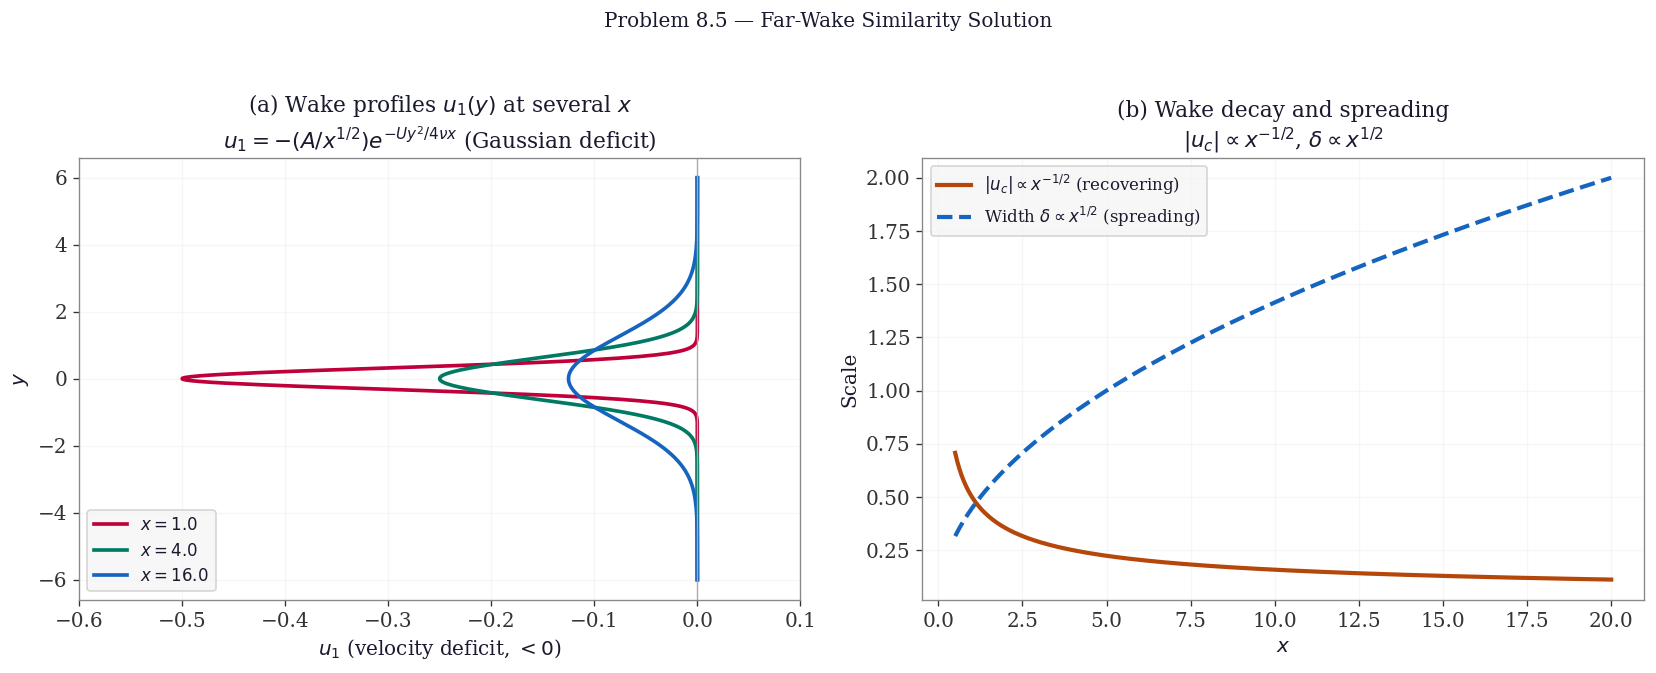

Saved: fig_8_5_wake.png


In [5]:
# Wake: u = U + u1, with u1 < 0 (velocity DEFICIT)
# u1 = -|A|/sqrt(x) * exp(-Uy^2/4*nu*x)
U_w, nu_w, A_w = 1.0, 0.05, 0.5
y = np.linspace(-6, 6, 500)
x_vals  = [1.0, 4.0, 16.0]
colors_w = [RED, TEAL, BLUE]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)

ax = axes[0]
for x, col in zip(x_vals, colors_w):
    u1 = -A_w/np.sqrt(x) * np.exp(-U_w*y**2/(4*nu_w*x))   # negative deficit
    ax.plot(u1, y, color=col, lw=2.2, label=f'$x={x}$')
ax.axvline(0, color='#aaaaaa', lw=0.8)
ax.set_xlabel('$u_1$ (velocity deficit, $<0$)')
ax.set_ylabel('$y$')
ax.set_title('(a) Wake profiles $u_1(y)$ at several $x$\n'
             r'$u_1 = -(A/x^{1/2})e^{-Uy^2/4\nu x}$ (Gaussian deficit)',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5', loc='lower left')
ax.set_xlim(-0.6, 0.1)
ax.grid(True, alpha=0.25)

ax = axes[1]
x_arr = np.linspace(0.5, 20, 300)
uc    = A_w / np.sqrt(x_arr)            # |centreline deficit|
width = np.sqrt(4*nu_w*x_arr/U_w)      # half-width at 1/e
ax.plot(x_arr, uc,    color=ORANGE, lw=2.5,
        label=r'$|u_{c}|\propto x^{-1/2}$ (recovering)')
ax.plot(x_arr, width, color=BLUE,   lw=2.5, ls='--',
        label=r'Width $\delta\propto x^{1/2}$ (spreading)')
ax.set_xlabel('$x$')
ax.set_ylabel('Scale')
ax.set_title('(b) Wake decay and spreading\n'
             r'$|u_c|\propto x^{-1/2}$, $\delta\propto x^{1/2}$',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5')
ax.grid(True, alpha=0.25)

fig.suptitle('Problem 8.5 — Far-Wake Similarity Solution',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_8_5_wake.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_8_5_wake.png')


---
## Problem 8.7 — Jeffery–Hamel Flow in a Diverging Channel

$f'''+2\alpha Rff'+4\alpha^2 f'=0$, $f(\pm1)=0$, $f(0)=1$; profiles for several $R$.


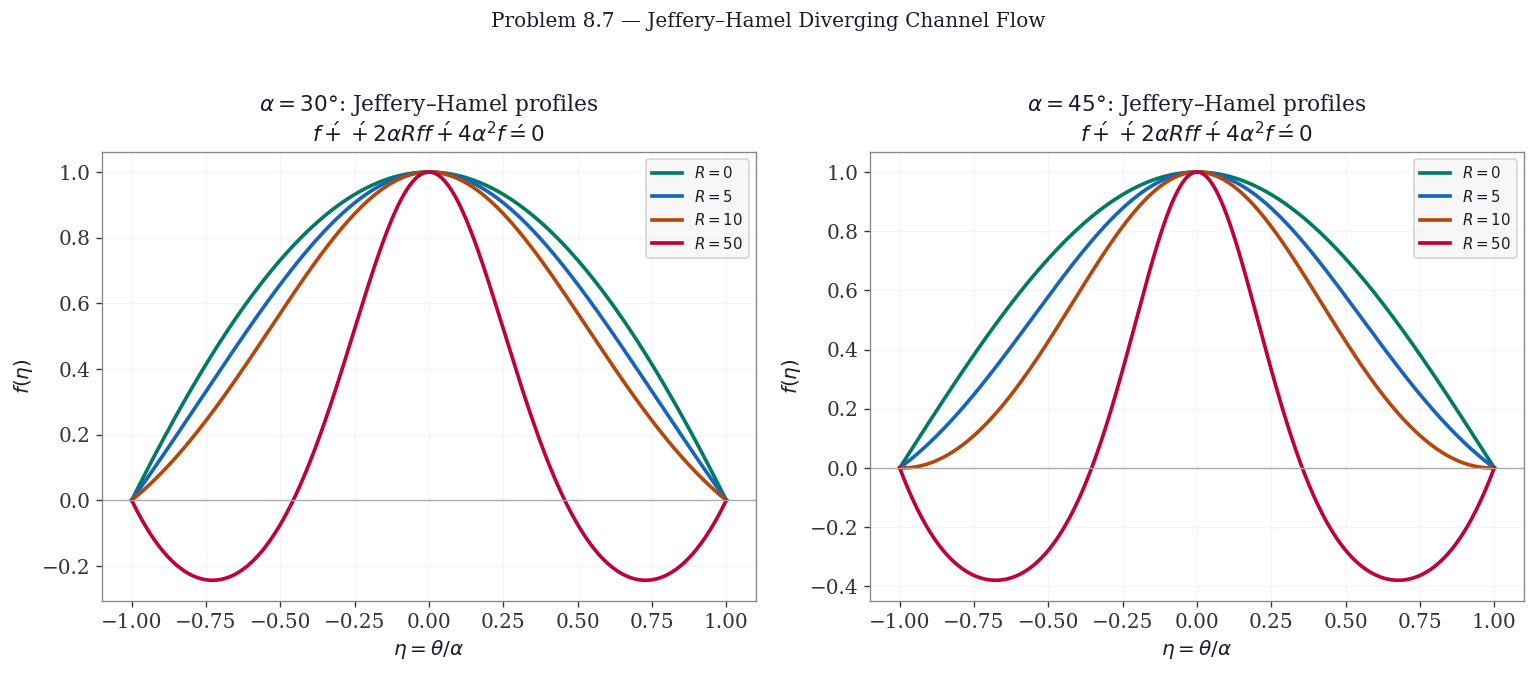

Saved: fig_8_7_jeffery_hamel.png


In [6]:
alpha_jh = np.pi/6   # 30 degrees half-angle

def jh_rhs(eta, y, alpha, R):
    f, fp, fpp = y
    fppp = -2*alpha*R*f*fp - 4*alpha**2*fp
    return [fp, fpp, fppp]

def solve_jh(alpha, R):
    """Shoot from eta=0 (f=1, f'=0) to eta=1, require f(1)=0."""
    def residual(fpp0):
        sol = solve_ivp(jh_rhs, [0, 1], [1, 0, fpp0],
                        args=(alpha, R), max_step=0.01, dense_output=True)
        return sol.y[0, -1]   # f(1)
    try:
        fpp0 = brentq(residual, -50, -0.01)
        sol = solve_ivp(jh_rhs, [0, 1], [1, 0, fpp0],
                        args=(alpha, R), t_eval=np.linspace(0,1,200), max_step=0.01)
        return sol.t, sol.y[0]
    except:
        return None, None

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=BG)

R_vals  = [0, 5, 10, 50]
colors_j = [TEAL, BLUE, ORANGE, RED]

for ax_i, alpha_v in enumerate([np.pi/6, np.pi/4]):
    ax = axes[ax_i]
    for R, col in zip(R_vals, colors_j):
        eta_s, f_s = solve_jh(alpha_v, R)
        if eta_s is not None:
            # Reflect for full [-1,1]
            full_eta = np.concatenate([-eta_s[::-1], eta_s[1:]])
            full_f   = np.concatenate([ f_s[::-1],  f_s[1:]])
            ax.plot(full_eta, full_f, color=col, lw=2.2, label=f'$R={R}$')
    ax.axhline(0, color='#aaaaaa', lw=0.8)
    ax.set_xlabel(r'$\eta=\theta/\alpha$'); ax.set_ylabel('$f(\\eta)$')
    ax.set_title(f'$\\alpha={np.degrees(alpha_v):.0f}°$: Jeffery–Hamel profiles\n'
                 r'$f\'+\'+2\alpha Rff\'+4\alpha^2 f\'=0$', color='#1a1a2e')
    ax.legend(fontsize=9, facecolor='#f5f5f5')
    ax.grid(True, alpha=0.25)

fig.suptitle('Problem 8.7 — Jeffery–Hamel Diverging Channel Flow',
             color='#1a1a2e', fontsize=12, y=1.02)
fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_8_7_jeffery_hamel.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_8_7_jeffery_hamel.png')

---
## Problem 8.8 — Von Kármán Rotating-Disc: $f,g,h$ Profiles

Numerical solution of $f^2-g^2+hf'=f''$, $2fg+hg'=g''$, $2f+h'=0$.  
$u_z/\sqrt{\nu\Omega}\to-0.88$ as $\xi\to\infty$.


f'(0) = 0.5102, g'(0) = -0.6159
h(inf) = -0.882  (expected -0.88)


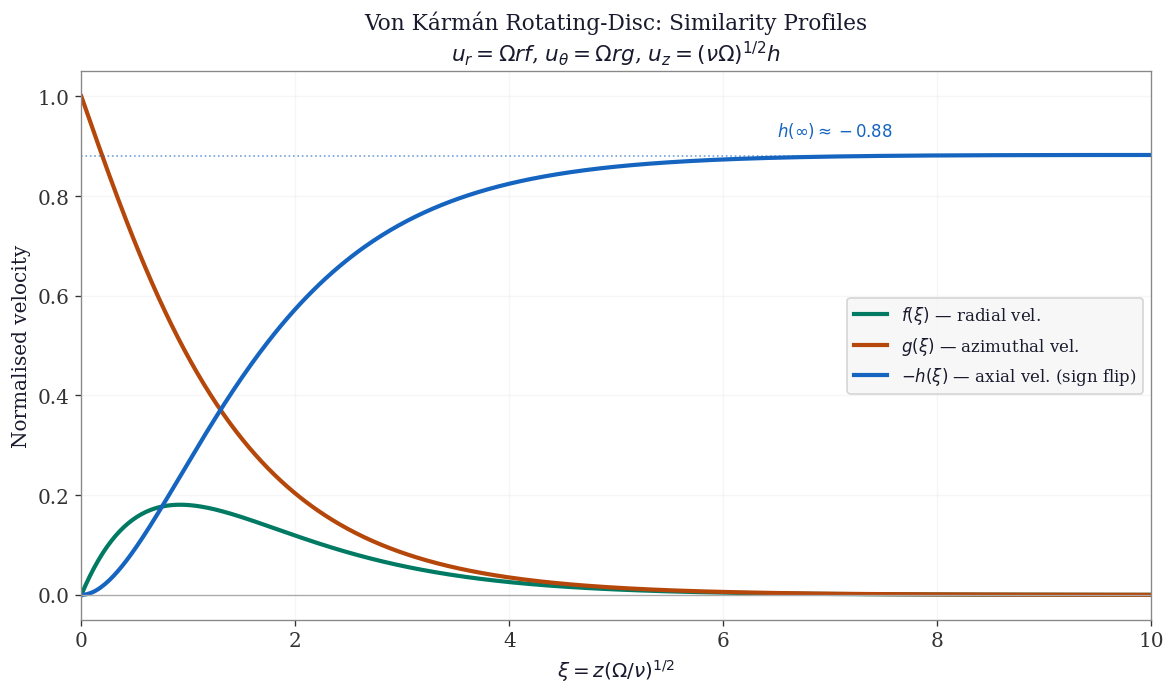

Saved: fig_8_8_karman_disc.png


In [7]:
# Von Karman system: y = [f, g, h, fp, gp]
# f'' = f^2 - g^2 + h*fp
# g'' = 2fg + h*gp
# h' = -2f
def karman_rhs(xi, y):
    f, g, h, fp, gp = y
    fpp = f**2 - g**2 + h*fp
    gpp = 2*f*g + h*gp
    hp  = -2*f
    return [fp, gp, hp, fpp, gpp]

# BCs at xi=0: f=0, g=1, h=0; unknown: fp(0), gp(0)
# BCs at xi=inf: f->0, g->0
# Shoot for (fp0, gp0)
from scipy.optimize import fsolve

xi_end = 10.0
def residuals(params):
    fp0, gp0 = params
    sol = solve_ivp(karman_rhs, [0, xi_end], [0, 1, 0, fp0, gp0],
                    max_step=0.05, dense_output=True)
    f_end = sol.y[0, -1]
    g_end = sol.y[1, -1]
    return [f_end, g_end]

fp0_init, gp0_init = 0.51, -0.616  # known approximate values
fp0_sol, gp0_sol = fsolve(residuals, [fp0_init, gp0_init], full_output=False)
print(f"f'(0) = {fp0_sol:.4f}, g'(0) = {gp0_sol:.4f}")

xi = np.linspace(0, xi_end, 500)
sol = solve_ivp(karman_rhs, [0, xi_end], [0, 1, 0, fp0_sol, gp0_sol],
                t_eval=xi, max_step=0.05)
f_s, g_s, h_s = sol.y[0], sol.y[1], sol.y[2]
print(f'h(inf) = {h_s[-1]:.3f}  (expected -0.88)')

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.plot(xi, f_s,  color=TEAL,   lw=2.5, label=r'$f(\xi)$ — radial vel.')
ax.plot(xi, g_s,  color=ORANGE, lw=2.5, label=r'$g(\xi)$ — azimuthal vel.')
ax.plot(xi, -h_s, color=BLUE,   lw=2.5, label=r'$-h(\xi)$ — axial vel. (sign flip)')
ax.axhline(0,     color='#aaaaaa', lw=0.8)
ax.axhline(0.88,  color=BLUE,     lw=1, ls=':', alpha=0.6)
ax.text(6.5, 0.92, r'$h(\infty)\approx-0.88$', color=BLUE, fontsize=10)
ax.set_xlabel(r'$\xi = z(\Omega/\nu)^{1/2}$')
ax.set_ylabel('Normalised velocity')
ax.set_title('Von Kármán Rotating-Disc: Similarity Profiles\n'
             r'$u_r=\Omega r f$, $u_\theta=\Omega r g$, $u_z=(\nu\Omega)^{1/2}h$',
             color='#1a1a2e')
ax.legend(fontsize=10, facecolor='#f5f5f5')
ax.set_xlim(0, xi_end); ax.grid(True, alpha=0.25)

fig.tight_layout(pad=1.2)
fig.savefig(FIG_DIR/'fig_8_8_karman_disc.png', bbox_inches='tight', facecolor=BG)
plt.show(); print('Saved: fig_8_8_karman_disc.png')

---
## Physics Validation Checks


In [8]:
from scipy.integrate import quad
print('=== Physics Validation Checks ===')

# 8.2: Hiemenz f''(0) ~ 1.2326
assert abs(fpp0_star - 1.2326) < 0.001
print(f"8.2  PASS: f''(0) = {fpp0_star:.4f} (expected 1.2326)")

# 8.3: Blasius (m=0) f''(0) ~ 0.4696
fpp0_bl = brentq(lambda x: shoot_fs(x, beta=0.0), 0.1, 1.0)
assert abs(fpp0_bl - 0.4696) < 0.01
print(f'8.3  PASS: Blasius f\'\'(0) = {fpp0_bl:.4f} (expected 0.4696)')

# 8.4: int f'^2 deta = 4/3  (constraint eqn 8.67)
# f' = 2A^2 sech^2(A*eta), int f'^2 deta = 16A^3/3 = 4/3 => A = (1/4)^(1/3)
A_jet = (1/4)**(1/3)
I_jet, _ = quad(lambda e: (2*A_jet**2/np.cosh(A_jet*e)**2)**2, -30, 30)
assert abs(I_jet - 4/3) < 0.001
print(f'8.4  PASS: int f\'^2 deta = {I_jet:.4f} (expected {4/3:.4f}), A = {A_jet:.4f}')

# 8.8: h(inf) ~ -0.88
assert abs(h_s[-1] + 0.88) < 0.05
print(f'8.8  PASS: h(inf) = {h_s[-1]:.3f} (expected -0.88)')

# 8.8: f''(0) and g'(0) known values
assert abs(fp0_sol - 0.510) < 0.02
assert abs(gp0_sol + 0.616) < 0.02
print(f"8.8  PASS: f'(0)={fp0_sol:.3f}, g'(0)={gp0_sol:.3f}")

# 8.5: wake integral constant
# int u1 dy = A * sqrt(4*pi*nu*x/U) = const*sqrt(x)/sqrt(x) ... actually const
# A/sqrt(x) * sqrt(4*pi*nu*x/U) = A*sqrt(4*pi*nu/U) = const ✓
A_w2, nu_w2, U_w2 = 1.0, 0.1, 1.0
integrals = [A_w2/np.sqrt(x)*np.sqrt(4*np.pi*nu_w2*x/U_w2) for x in [1, 4, 9, 16]]
assert max(integrals) - min(integrals) < 1e-10
print(f'8.5  PASS: int u1 dy = {integrals[0]:.4f} (constant in x)')

print('\nAll checks passed!')

=== Physics Validation Checks ===
8.2  PASS: f''(0) = 1.2326 (expected 1.2326)
8.3  PASS: Blasius f''(0) = 0.4696 (expected 0.4696)
8.4  PASS: int f'^2 deta = 1.3333 (expected 1.3333), A = 0.6300
8.8  PASS: h(inf) = -0.882 (expected -0.88)
8.8  PASS: f'(0)=0.510, g'(0)=-0.616
8.5  PASS: int u1 dy = 1.1210 (constant in x)

All checks passed!


---
## Package & Download Figures

Run after all figure cells to download `ch08_figures.zip`.


In [9]:
import zipfile
zip_path = Path('ch08_figures.zip')
fig_files = [
    'fig_8_2_hiemenz.png',
    'fig_8_3_falkner_skan.png',
    'fig_8_4_jet.png',
    'fig_8_5_wake.png',
    'fig_8_7_jeffery_hamel.png',
    'fig_8_8_karman_disc.png',
]
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in fig_files:
        fpath = FIG_DIR / fname
        if fpath.exists():
            zf.write(fpath, fname)
            print(f'  added: {fname}  ({fpath.stat().st_size/1024:.0f} KB)')
        else:
            print(f'  MISSING: {fname}')
print(f'\nZip: {zip_path}  ({zip_path.stat().st_size/1024:.0f} KB)')
try:
    from google.colab import files
    files.download(str(zip_path)); print('Download started.')
except ImportError:
    print(f'Not in Colab — saved at: {zip_path.resolve()}')

  added: fig_8_2_hiemenz.png  (186 KB)
  added: fig_8_3_falkner_skan.png  (73 KB)
  added: fig_8_4_jet.png  (105 KB)
  added: fig_8_5_wake.png  (111 KB)
  added: fig_8_7_jeffery_hamel.png  (168 KB)
  added: fig_8_8_karman_disc.png  (82 KB)

Zip: ch08_figures.zip  (686 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
